        Date     Category  Sales
0 2023-01-01     Clothing   1458
1 2023-01-02     Clothing    985
2 2023-01-03  Electronics   1640
3 2023-01-04  Electronics   1561
4 2023-01-05     Clothing   1969


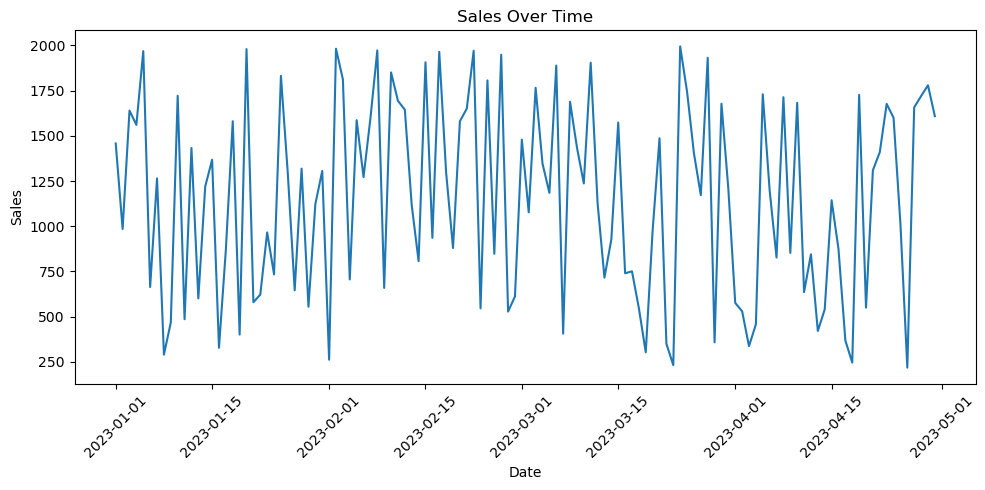

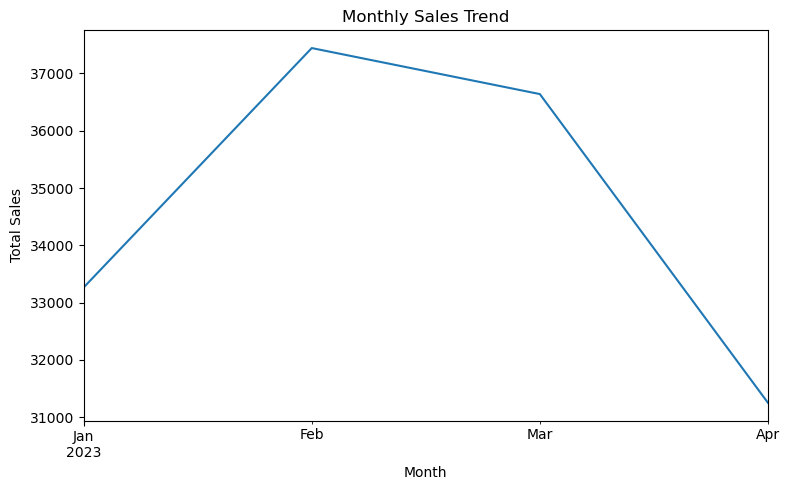

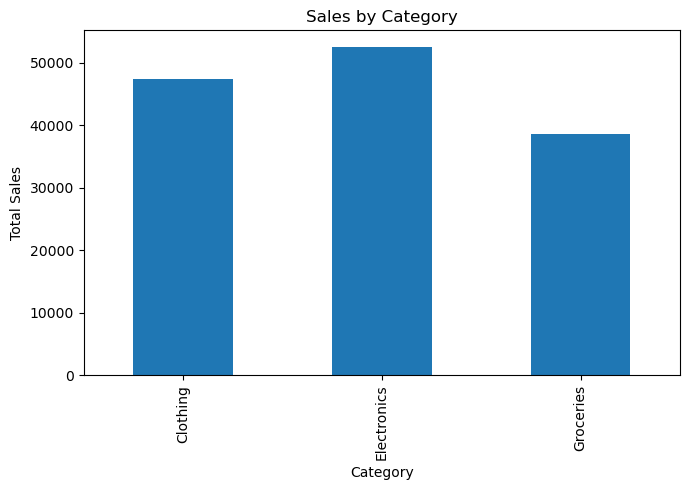

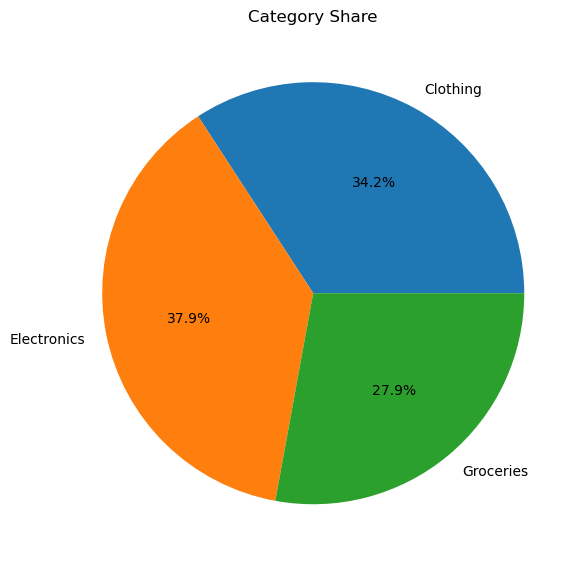


Summary:
Total Sales: 138600
Best Category: Electronics
Highest Sales Month: 2023-02


In [1]:
# ==========================================
# PROJECT 1 - Time Series & Category Charts
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Create a sample sales dataset
np.random.seed(10)

dates = pd.date_range(start="2023-01-01", periods=120, freq="D")

data = {
    "Date": dates,
    "Category": np.random.choice(["Electronics", "Clothing", "Groceries"], 120),
    "Sales": np.random.randint(200, 2000, 120)
}

df = pd.DataFrame(data)

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print(df.head())

# ---------------------------------------------------
# 1. LINE CHART – Sales over time
# ---------------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Sales"])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("line_chart_sales.png")
plt.show()

# ---------------------------------------------------
# 2. MONTHLY SALES AGGREGATION
# ---------------------------------------------------

df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="line")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

# ---------------------------------------------------
# 3. BAR CHART – Category Comparison
# ---------------------------------------------------

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.savefig("bar_chart_category.png")
plt.show()

# ---------------------------------------------------
# 4. PIE CHART – Category Share
# ---------------------------------------------------

plt.figure(figsize=(6,6))
category_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Category Share")
plt.ylabel("")
plt.tight_layout()
plt.savefig("pie_chart_category.png")
plt.show()

# ---------------------------------------------------
# 5. SHORT SUMMARY
# ---------------------------------------------------

print("\nSummary:")
print("Total Sales:", df["Sales"].sum())
print("Best Category:", category_sales.idxmax())
print("Highest Sales Month:", monthly_sales.idxmax())